In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('crop_yield.csv')

print(df.shape)
print(df.dtypes)
df.head()

(1000000, 10)
Region                        str
Soil_Type                     str
Crop                          str
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition             str
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [2]:
# Basic exploration
print("Missing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

print("\nCrop types:", df['Crop'].unique())
print("Regions:", df['Region'].unique())
print("Soil types:", df['Soil_Type'].unique())

Missing values:
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

Basic statistics:
          Rainfall_mm  Temperature_Celsius  Days_to_Harvest  \
count  1000000.000000       1000000.000000   1000000.000000   
mean       549.981901            27.504965       104.495025   
std        259.851320             7.220608        25.953412   
min        100.000896            15.000034        60.000000   
25%        324.891090            21.254502        82.000000   
50%        550.124061            27.507365       104.000000   
75%        774.738520            33.753267       127.000000   
max        999.998098            39.999997       149.000000   

       Yield_tons_per_hectare  
count          1000000.000000  
mean                 4.649472  
std     

/var/folders/5x/cx4dbrdd2jj105gn86s5pyyh0000gn/T/ipykernel_62617/2524245335.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crop_yield.index, y=crop_yield.values, palette='viridis')


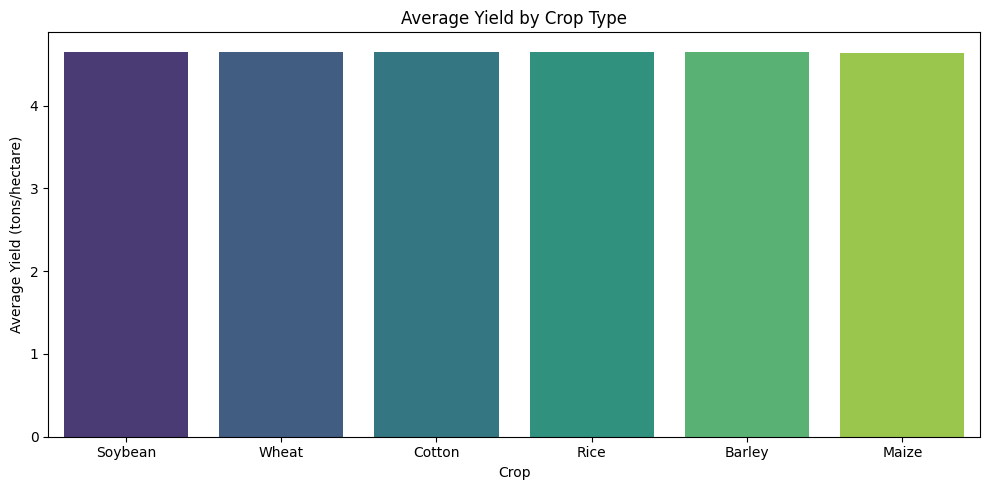

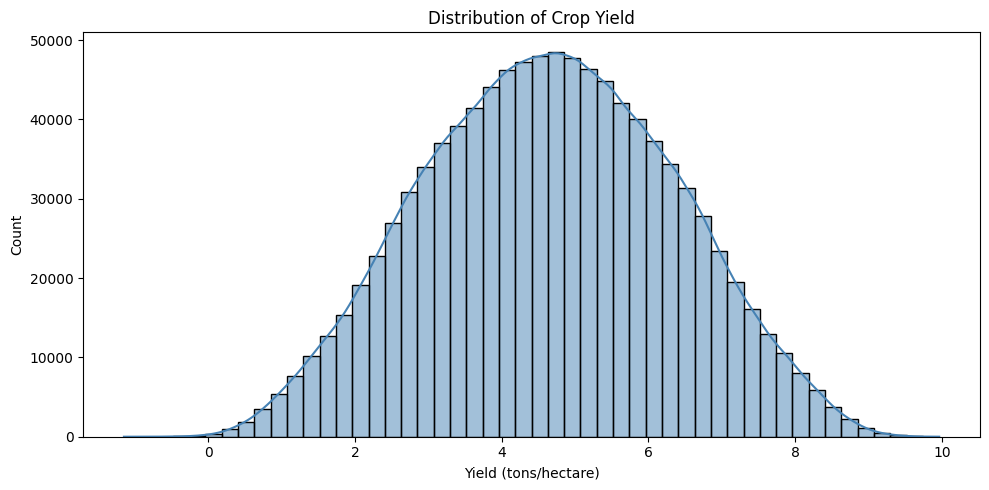

In [3]:
# Visualisation 1: Average yield by crop type
plt.figure(figsize=(10, 5))
crop_yield = df.groupby('Crop')['Yield_tons_per_hectare'].mean().sort_values(ascending=False)
sns.barplot(x=crop_yield.index, y=crop_yield.values, palette='viridis')
plt.title('Average Yield by Crop Type')
plt.xlabel('Crop')
plt.ylabel('Average Yield (tons/hectare)')
plt.tight_layout()
plt.savefig('avg_yield_by_crop.png', dpi=150)
plt.show()

# Visualisation 2: Yield distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Yield_tons_per_hectare'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (tons/hectare)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('yield_distribution.png', dpi=150)
plt.show()

/var/folders/5x/cx4dbrdd2jj105gn86s5pyyh0000gn/T/ipykernel_62617/617078234.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Region', y='Yield_tons_per_hectare', palette='Set2')


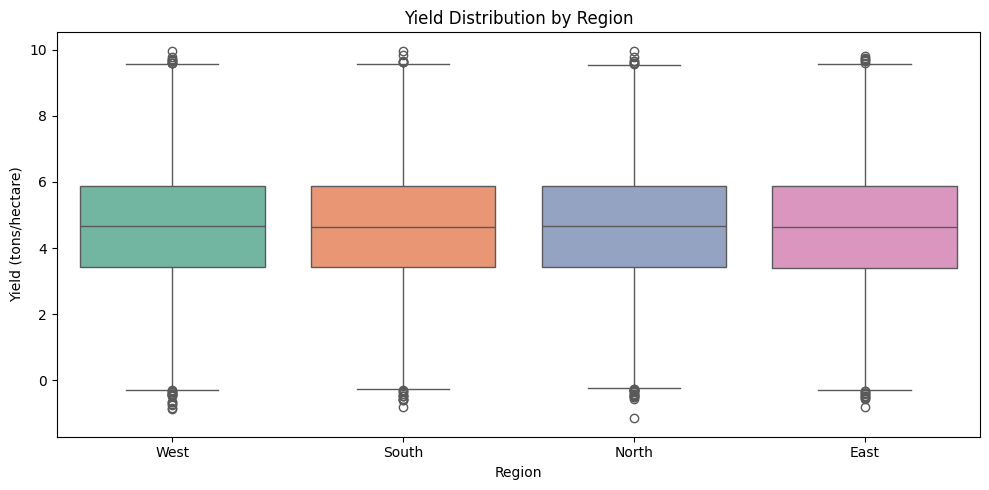

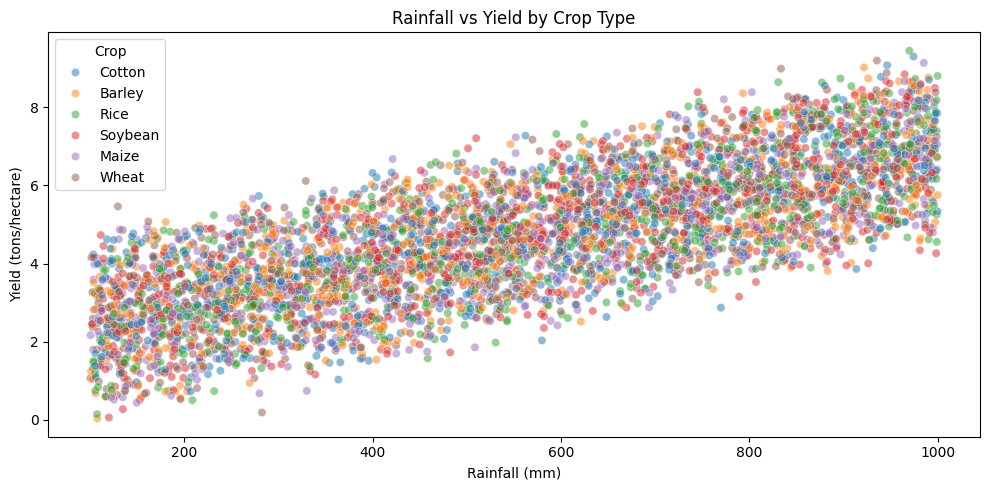

In [4]:
# Visualisation 3: Yield by region
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Region', y='Yield_tons_per_hectare', palette='Set2')
plt.title('Yield Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Yield (tons/hectare)')
plt.tight_layout()
plt.savefig('yield_by_region.png', dpi=150)
plt.show()

# Visualisation 4: Rainfall vs Yield
plt.figure(figsize=(10, 5))
sample = df.sample(5000, random_state=42)
sns.scatterplot(data=sample, x='Rainfall_mm', y='Yield_tons_per_hectare', 
                hue='Crop', alpha=0.5)
plt.title('Rainfall vs Yield by Crop Type')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (tons/hectare)')
plt.tight_layout()
plt.savefig('rainfall_vs_yield.png', dpi=150)
plt.show()